# ДЗ №2. Аппроксимация функции в PyTorch

**Цель**  
Нужно создать и обучить регрессионную модель, которая аппроксимирует значение функции

$$
f(x,y)=\sin(x+2y)\,\exp\left(-(2x+y)^2\right), \qquad x,y\in[-10,10].
$$

**Описание**

1. сгенерировать **20 000** случайных точек;
2. разделить их на `train / test / val  ~ 70% / 15% / 15%`;
3. подготовить `Dataset` и `DataLoader`;
4. создать полносвязную нейросеть;
5. посчитать метрику **MSE** на `test`;
6. нарисовать график, в котором сравнивается истинная функция и ее аппроксимированный вариант.



## Подготовка и параметры

In [373]:
import copy
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Устройство:", device)

def set_seed(seed: int = 30):
    """Задаёт seed для Python, NumPy и PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

SEED = 59
set_seed(SEED)

PyTorch: 2.14.1
Устройство: cpu


## Целевая функция и первичное исследование

Функция ниже работает сразу с тензором формы `(N, 2)`: первый столбец — $x$, второй — $y$. Результат имеет форму `(N, 1)`, что совпадает с выходом регрессионной нейросети.

In [374]:
def target_function(X):
    """Вычисляет f(x, y) для тензора X формы (N, 2)."""
    x = X[:, 0:1]
    y = X[:, 1:2]
    return torch.sin(x + 2 * y) * torch.exp(-(2 * x + y) ** 2)

# Быстрая проверка формы и нескольких значений
demo_X = torch.tensor([[0.0, 0.0], [1.0, -2.0], [2.0, -1.0]])
demo_y = target_function(demo_X)
print("X shape:", demo_X.shape)
print("y shape:", demo_y.shape)
print(torch.cat([demo_X, demo_y], dim=1))

X shape: torch.Size([3, 2])
y shape: torch.Size([3, 1])
tensor([[ 0.0000,  0.0000,  0.0000],
        [ 1.0000, -2.0000, -0.1411],
        [ 2.0000, -1.0000,  0.0000]])


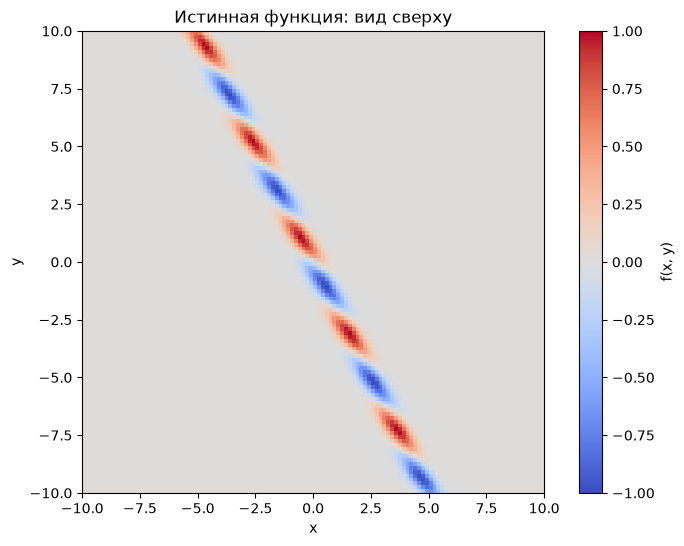

In [375]:
# Посмотрим на истинную функцию на регулярной сетке
grid_size_preview = 120
x_axis = torch.linspace(-10, 10, grid_size_preview)
y_axis = torch.linspace(-10, 10, grid_size_preview)
X_grid, Y_grid = torch.meshgrid(x_axis, y_axis, indexing="xy")
grid_points = torch.stack([X_grid.reshape(-1), Y_grid.reshape(-1)], dim=1)

Z_true_preview = target_function(grid_points).reshape(grid_size_preview, grid_size_preview)

plt.figure(figsize=(9, 6))
plt.imshow(
    Z_true_preview.numpy(), origin="lower", extent=[-10, 10, -10, 10],
    cmap="coolwarm", vmin=-1, vmax=1, aspect="equal"
)
plt.colorbar(label="f(x, y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Истинная функция: вид сверху")
plt.show()

> **NB!** Значимые значения сосредоточены около диагонали `2x + y = 0`.

## Подготовка выборок

### Генерация случайных точек

In [376]:
N_SAMPLES = 20_000
LOW, HIGH = -10.0, 10.0

# [0, 1) -> [-10,10)
X_all = LOW + (HIGH - LOW) * torch.rand(N_SAMPLES, 2)
y_all = target_function(X_all)

print("X_all:", X_all.shape, X_all.dtype)
print("y_all:", y_all.shape, y_all.dtype)
print("\nИнтервалы данных:\n")
print(f"x: [{X_all[:, 0].min():.3f}, {X_all[:, 0].max():.3f}]")
print(f"y: [{X_all[:, 1].min():.3f}, {X_all[:, 1].max():.3f}]")
print(f"target: [{y_all.min():.3f}, {y_all.max():.3f}]")

X_all: torch.Size([20000, 2]) torch.float32
y_all: torch.Size([20000, 1]) torch.float32

Интервалы данных:

x: [-10.000, 9.999]
y: [-9.997, 9.996]
target: [-0.999, 0.999]


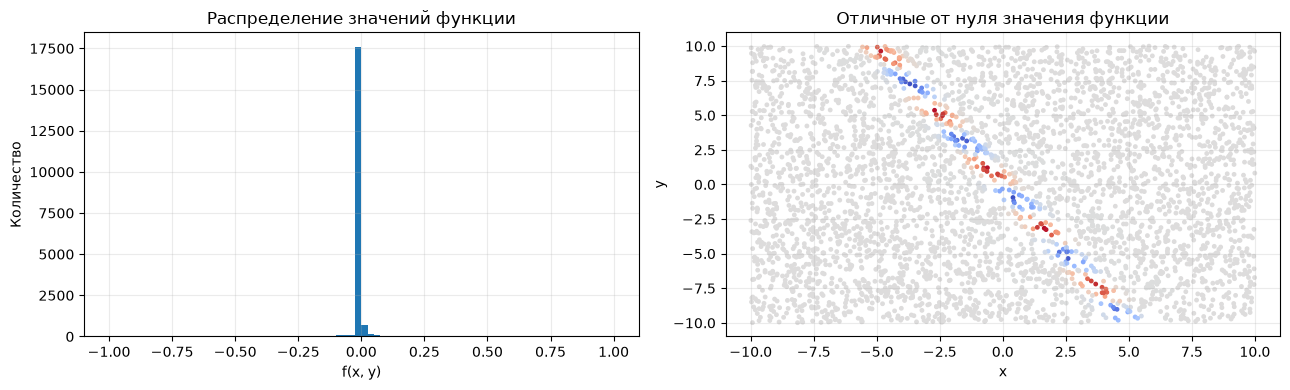

Доля значений "отличных от нуля" |f(x,y)| > 0.01: 10.0%


In [377]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# Посмотрим распределение значений на наших данных
axes[0].hist(y_all.numpy().ravel(), bins=80)
axes[0].set(title="Распределение значений функции", xlabel="f(x, y)", ylabel="Количество")
axes[0].grid(alpha=0.25)
# И значения на сетке из 4000 точек
axes[1].scatter(X_all[:4000, 0], X_all[:4000, 1], c=y_all[:4000, 0],
                s=6, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set(title="Отличные от нуля значения функции", xlabel="x", ylabel="y")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

non_zero = (y_all.abs() > 0.01).float().mean().item()
print(f"Доля значений \"отличных от нуля\" |f(x,y)| > 0.01: {non_zero:.1%}")

### Разбиение train / validation / test

Разделим наши данные на
- **train (70%)** — по ней будем обновлять веса;
- **validation (15%)** — по ней будем выбирать эпоху / отслеживать переобучение;
- **test (15%)** — будем независимо проверять модель.

Смешаем выборку и сделаем непересекающиеся срезы: 14 000 / 3 000 / 3 000 точек.

In [378]:
n_train = int(0.70 * N_SAMPLES)
n_val = int(0.15 * N_SAMPLES)
n_test = N_SAMPLES - n_train - n_val
# перестановки
permutation = torch.randperm(N_SAMPLES)
train_idx = permutation[:n_train]
val_idx = permutation[n_train:n_train + n_val]
test_idx = permutation[n_train + n_val:]
# разделяем данные
X_train_raw, y_train = X_all[train_idx], y_all[train_idx]
X_val_raw, y_val = X_all[val_idx], y_all[val_idx]
X_test_raw, y_test = X_all[test_idx], y_all[test_idx]
print("train:", X_train_raw.shape, y_train.shape)
print("val:  ", X_val_raw.shape, y_val.shape)
print("test: ", X_test_raw.shape, y_test.shape)
# доп проверка для себя
assert len(X_train_raw) == 14_000
assert len(X_val_raw) == 3_000
assert len(X_test_raw) == 3_000
assert len(set(train_idx.tolist()) & set(val_idx.tolist())) == 0
assert len(set(train_idx.tolist()) & set(test_idx.tolist())) == 0

train: torch.Size([14000, 2]) torch.Size([14000, 1])
val:   torch.Size([3000, 2]) torch.Size([3000, 1])
test:  torch.Size([3000, 2]) torch.Size([3000, 1])


### Нормализация

Для облегчения обучения, нормализуем только по медиане/отклонению **train** выборки для избежания "утечки" из `validation/test`.

Целевую переменную нормировать не обязательно: она уже находится примерно в `[-1, 1]`.

In [379]:
X_mean = X_train_raw.mean(dim=0, keepdim=True)
X_std = X_train_raw.std(dim=0, keepdim=True)

def normalize_X(X):
    return (X - X_mean) / X_std

X_train = normalize_X(X_train_raw)
X_val = normalize_X(X_val_raw)
X_test = normalize_X(X_test_raw)

print("meadn X_train: ", X_train.mean(dim=0))
print("std X_train: ", X_train.std(dim=0))

meadn X_train:  tensor([8.3106e-09, 1.8529e-08])
std X_train:  tensor([1., 1.])


### Dataset и DataLoader

Свяжем наши точки и значения функции в `TensorDataset`.

Используем `DataLoader` для батчей. Перемешивание ипользуем только для train.

In [380]:
BATCH_SIZE = 512

train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val, y_val), batch_size=1024, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test), batch_size=1024, shuffle=False
)

batch_X, batch_y = next(iter(train_loader))
print("batch info: ", batch_X.shape, batch_y.shape)
print("train batches count: ", len(train_loader))

batch info:  torch.Size([512, 2]) torch.Size([512, 1])
train batches count:  28


## Модель

Используем многослойный перцептрон c 3 скрытыми слоями и одним выходным:

2 входа (x, y) ->
1. Linear + Tanh (2, 128) ->
2. Linear + Tanh (128, 128) ->
3. Linear + Tanh (128, 64) ->
4. Linear (64, 1) → ответ

- `Linear` выполняет обучаемое линейное преобразование;
- `Tanh` добавляет нелинейность и хорошо подходит гладкой знакопеременной функции;
- последний слой **без активации**, потому что это регрессия, а ответ может быть как отрицательным, так и положительным.

In [381]:
class FunctionApproximator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.network(x)

model = FunctionApproximator().to(device)
print(model)
print("Обучаемых параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))

FunctionApproximator(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Обучаемых параметров: 25217


### Loss, optimizer и метрика

Для значения $i$ квадрат ошибки равен $(\hat y_i-y_i)^2$.

Метрика Mean Squared Error:
$$
\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat y_i)^2.
$$

В этой задаче используем `nn.MSELoss()` -- метод одновременно является функцией потерь для обучения и требуемой метрикой.

In [382]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=7e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=10, min_lr=1e-5
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: MSELoss()
Optimizer: Adam


In [383]:
def evaluate_mse(model, data_loader, device):
    """MSE по всем объектам loader, а не среднее mse всех batches."""
    model.eval()
    squared_error_sum = 0.0
    n_objects = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            squared_error_sum += ((predictions - y_batch) ** 2).sum().item()
            n_objects += y_batch.numel()

    return squared_error_sum / n_objects

## Обучение

После каждой эпохи измеряем train и validation MSE. Сохраняем копию весов при улучшении validation. Если улучшений долго нет, останавливаемся и возвращаемся к лучшим весам.

In [384]:
MAX_EPOCHS = 500
PATIENCE = 40
MIN_DELTA = 1e-7

history = {"train_mse": [], "val_mse": [], "lr": []}
best_val_mse = float("inf")
best_state = None
best_epoch = 0
epochs_without_improvement = 0
start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_squared_error_sum = 0.0
    train_n = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # learn step
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        # accum for mse
        train_squared_error_sum += ((predictions.detach() - y_batch) ** 2).sum().item()
        train_n += y_batch.numel()

    train_mse = train_squared_error_sum / train_n
    val_mse = evaluate_mse(model, val_loader, device)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_mse"].append(train_mse)
    history["val_mse"].append(val_mse)
    history["lr"].append(current_lr)

    if val_mse < best_val_mse - MIN_DELTA:
        best_val_mse = val_mse
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    scheduler.step(val_mse)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{MAX_EPOCHS} | "
            f"train MSE: {train_mse:.7f} | val MSE: {val_mse:.7f} | lr: {current_lr:.1e}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping на эпохе {epoch}.")
        break

model.load_state_dict(best_state)
elapsed = time.time() - start_time
print(f"\nЛучшая эпоха: {best_epoch}")
print(f"Лучшая validation MSE: {best_val_mse:.8f}")
print(f"Время обучения: {elapsed:.1f} сек.")

Epoch   1/500 | train MSE: 0.0672950 | val MSE: 0.0175866 | lr: 7.0e-03
Epoch  10/500 | train MSE: 0.0168235 | val MSE: 0.0160344 | lr: 7.0e-03
Epoch  20/500 | train MSE: 0.0169385 | val MSE: 0.0162664 | lr: 7.0e-03
Epoch  30/500 | train MSE: 0.0165152 | val MSE: 0.0152799 | lr: 7.0e-03
Epoch  40/500 | train MSE: 0.0145485 | val MSE: 0.0127800 | lr: 7.0e-03
Epoch  50/500 | train MSE: 0.0127620 | val MSE: 0.0127082 | lr: 7.0e-03
Epoch  60/500 | train MSE: 0.0105972 | val MSE: 0.0102926 | lr: 7.0e-03
Epoch  70/500 | train MSE: 0.0081618 | val MSE: 0.0076110 | lr: 7.0e-03
Epoch  80/500 | train MSE: 0.0032316 | val MSE: 0.0016752 | lr: 7.0e-03
Epoch  90/500 | train MSE: 0.0004303 | val MSE: 0.0004808 | lr: 7.0e-03
Epoch 100/500 | train MSE: 0.0004079 | val MSE: 0.0004348 | lr: 7.0e-03
Epoch 110/500 | train MSE: 0.0003462 | val MSE: 0.0002750 | lr: 7.0e-03
Epoch 120/500 | train MSE: 0.0002510 | val MSE: 0.0001979 | lr: 3.5e-03
Epoch 130/500 | train MSE: 0.0001617 | val MSE: 0.0002001 | lr: 

### Кривые обучения

Если train MSE уменьшается, а validation MSE начинает расти, это признак переобучения. Логарифмическая шкала помогает видеть изменения на нескольких порядках.

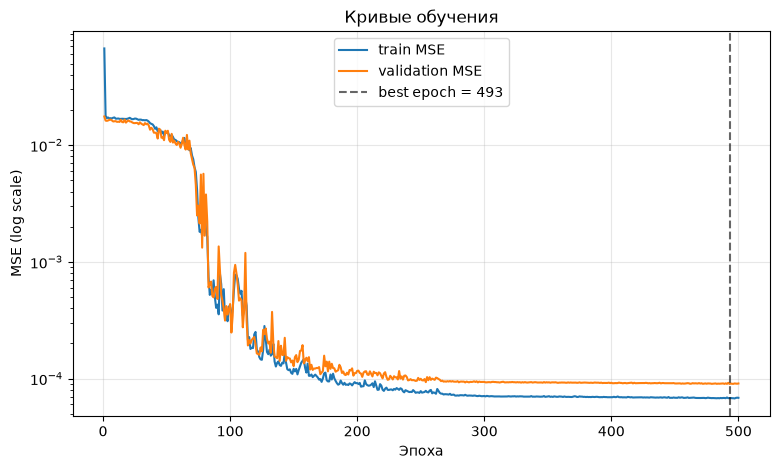

In [385]:
epochs_ran = np.arange(1, len(history["train_mse"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_ran, history["train_mse"], label="train MSE")
ax.plot(epochs_ran, history["val_mse"], label="validation MSE")
ax.axvline(best_epoch, color="black", linestyle="--", alpha=0.6,
           label=f"best epoch = {best_epoch}")
ax.set_yscale("log")
ax.set(xlabel="Эпоха", ylabel="MSE (log scale)", title="Кривые обучения")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### Оценка MSE

После обучения на `train` и выбора лучших весов по `validation`, проверим метрику для `test` данных. 

Заметим, что исходная функция почти везде равна 0. Поэтому сравним MSE нашей модели и очевидного предсказания в виде нуль-функции.
Хорошая модель должна обойти такое предсказание...

Дополнительно оценим MSE на значимых точках: выбираем их по истинному значению `|target| > 0.1`. 


In [386]:
test_mse = evaluate_mse(model, test_loader, device)

zero_fun_mse = torch.mean(y_test ** 2).item()
improvement = (zero_fun_mse - test_mse) / zero_fun_mse

print(f"TEST MSE нашей модели: {test_mse:.8f}")
print(f"TEST MSE нуль-функции: {zero_fun_mse:.8f}")
print(f"Улучшение относительно тривиального предположения: {improvement:.1%}")

TEST MSE нашей модели: 0.00004943
TEST MSE нуль-функции: 0.01497243
Улучшение относительно тривиального предположения: 99.7%


In [387]:
# Рассмотрим MSE для значимых точек (не-нулевое значение целевой функции)
model.eval()
with torch.no_grad():
    test_predictions = model(X_test.to(device)).cpu()

important_mask = y_test.abs().squeeze(1) > 0.1
n_important = important_mask.sum().item()
print(f"Значимых test-точек: {n_important} из {len(y_test)}")
important_mse = torch.mean(
    (test_predictions[important_mask] - y_test[important_mask]) ** 2
).item()
print(f"MSE модели при |target| > 0.1: {important_mse:.8f}")

Значимых test-точек: 178 из 3000
MSE модели при |target| > 0.1: 0.00068898


### Сравнение истинной и предсказанной функций

Для наглядной визуализации используем отдельную регулярную сетку.

In [388]:
GRID_SIZE = 120
x_axis = torch.linspace(-10, 10, GRID_SIZE)
y_axis = torch.linspace(-10, 10, GRID_SIZE)
X_grid, Y_grid = torch.meshgrid(x_axis, y_axis, indexing="xy")
grid_raw = torch.stack([X_grid.reshape(-1), Y_grid.reshape(-1)], dim=1)

with torch.no_grad():
    Z_true = target_function(grid_raw).reshape(GRID_SIZE, GRID_SIZE).numpy()
    grid_normalized = normalize_X(grid_raw)
    Z_pred = model(grid_normalized.to(device)).cpu().reshape(GRID_SIZE, GRID_SIZE).numpy()

Z_error = np.abs(Z_true - Z_pred)
print("MSE на регулярной сетке:", np.mean((Z_true - Z_pred) ** 2))
print("Максимальная абсолютная ошибка на сетке:", Z_error.max())

MSE на регулярной сетке: 9.447463e-05
Максимальная абсолютная ошибка на сетке: 0.2702899


Рассмотрим 3d визуализацию

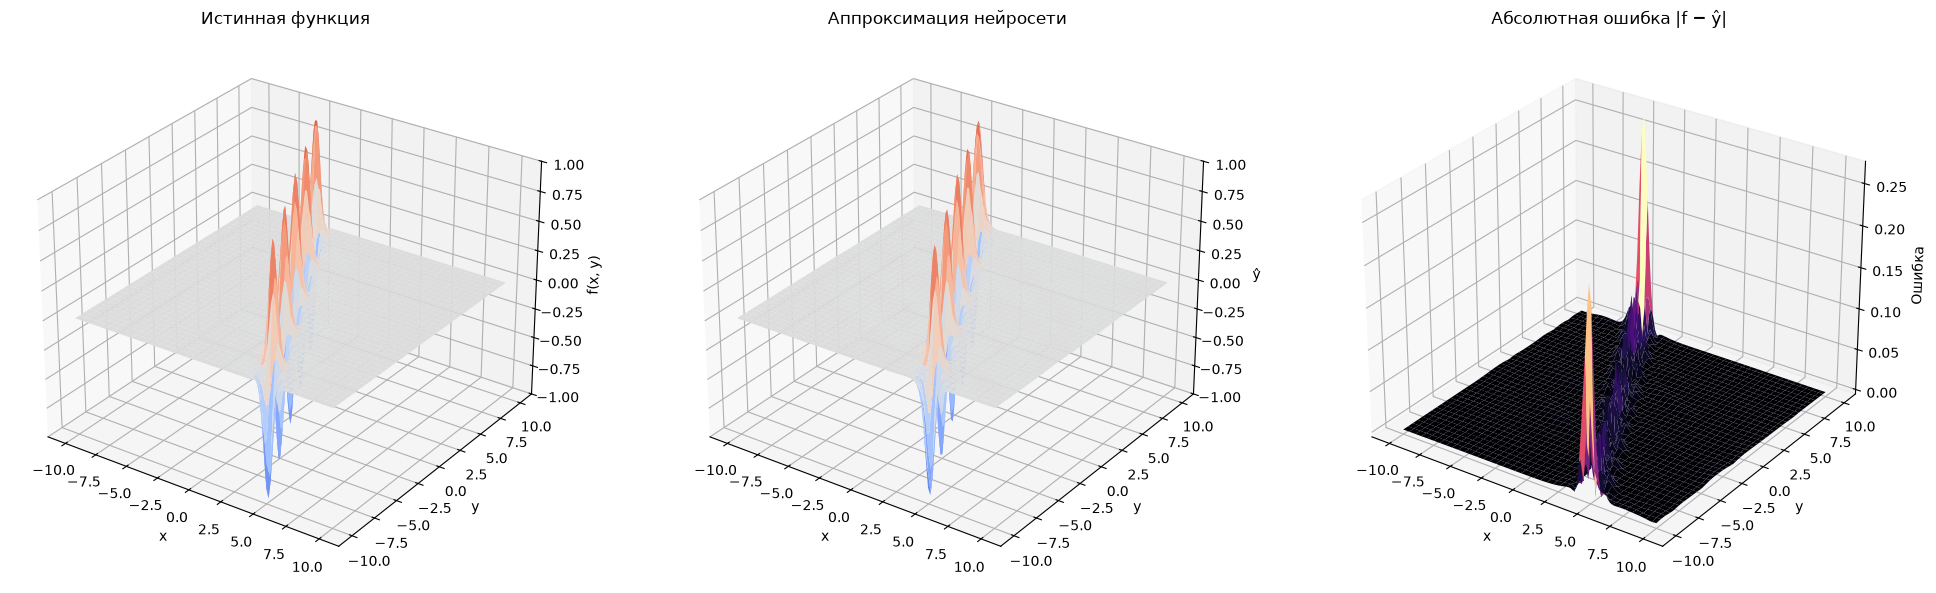

In [389]:
fig = plt.figure(figsize=(20, 6))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
ax1.plot_surface(X_grid.numpy(), Y_grid.numpy(), Z_true,
                 cmap="coolwarm", vmin=-1, vmax=1, linewidth=0, antialiased=True)
ax1.set(title="Истинная функция", xlabel="x", ylabel="y", zlabel="f(x, y)")
ax1.set_zlim(-1, 1)
ax1.view_init(elev=28, azim=-55)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(X_grid.numpy(), Y_grid.numpy(), Z_pred,
                 cmap="coolwarm", vmin=-1, vmax=1, linewidth=0, antialiased=True)
ax2.set(title="Аппроксимация нейросети", xlabel="x", ylabel="y", zlabel="ŷ")
ax2.set_zlim(-1, 1)
ax2.view_init(elev=28, azim=-55)

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
ax3.plot_surface(X_grid.numpy(), Y_grid.numpy(), Z_error,
                 cmap="magma", linewidth=0, antialiased=True)
ax3.set(title="Абсолютная ошибка |f − ŷ|", xlabel="x", ylabel="y", zlabel="Ошибка")
ax3.view_init(elev=28, azim=-55)

plt.tight_layout()
plt.show()

Ниже — вид сверху в одинаковой цветовой шкале.

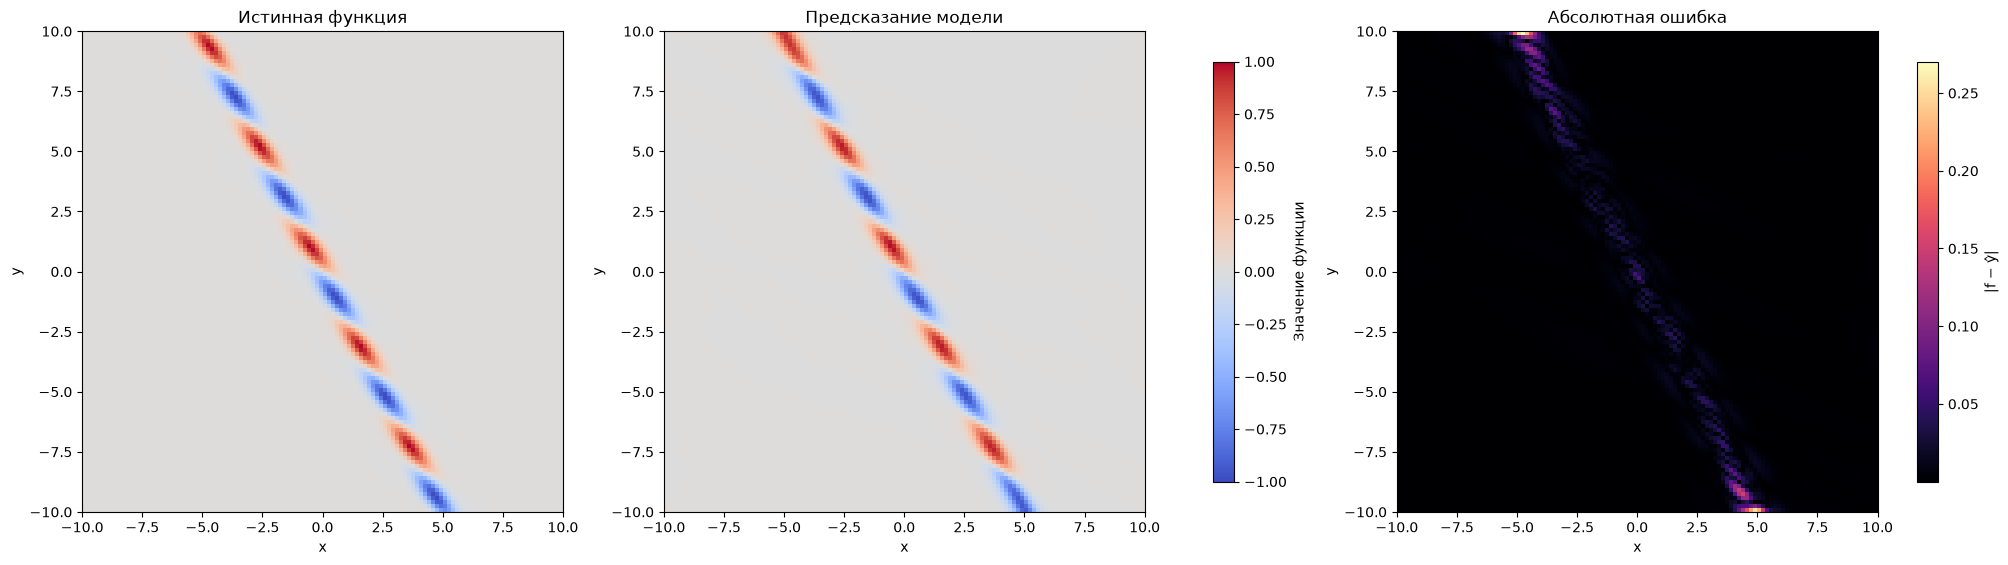

In [390]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), constrained_layout=True)

im0 = axes[0].imshow(Z_true, origin="lower", extent=[-10, 10, -10, 10],
                     cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")
axes[0].set_title("Истинная функция")

im1 = axes[1].imshow(Z_pred, origin="lower", extent=[-10, 10, -10, 10],
                     cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")
axes[1].set_title("Предсказание модели")

im2 = axes[2].imshow(Z_error, origin="lower", extent=[-10, 10, -10, 10],
                     cmap="magma", aspect="equal")
axes[2].set_title("Абсолютная ошибка")

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.colorbar(im0, ax=axes[:2], shrink=0.85, label="Значение функции")
fig.colorbar(im2, ax=axes[2], shrink=0.85, label="|f − ŷ|")
plt.show()